model comparison - wine dataset
---------------------------------------------
svm
  test accuracy: 1.0
  cv accuracy:   0.983
knn
  test accuracy: 0.944
  cv accuracy:   0.955
logistic regression
  test accuracy: 1.0
  cv accuracy:   0.989


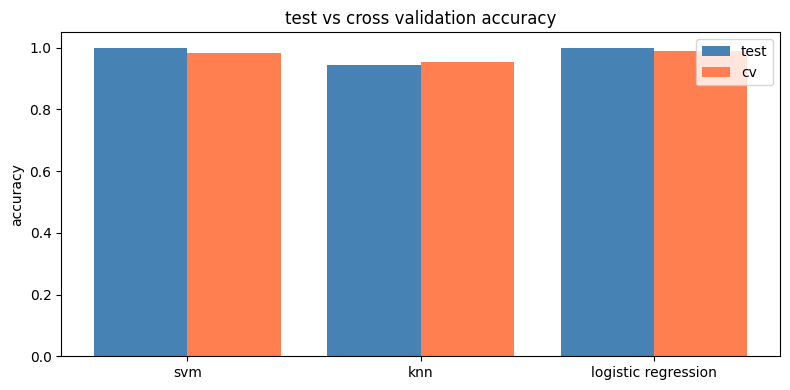

In [4]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

wine = load_wine()
x = wine.data
y = wine.target

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)

models = {
    "svm":                 SVC(kernel="rbf", random_state=42),
    "knn":                 KNeighborsClassifier(n_neighbors=5),
    "logistic regression": LogisticRegression(max_iter=1000)
}

print("model comparison - wine dataset")
print("-" * 45)

scores = {}
cv_scores = {}

for name, model in models.items():
    model.fit(x_train, y_train)
    test_score = round(model.score(x_test, y_test), 3)
    cv = round(np.mean(cross_val_score(model, x_scaled, y, cv=5)), 3)
    scores[name] = test_score
    cv_scores[name] = cv
    print(name)
    print("  test accuracy:", test_score)
    print("  cv accuracy:  ", cv)

plt.figure(figsize=(8, 4))
x_pos = range(len(models))
plt.bar([p - 0.2 for p in x_pos], scores.values(),
        width=0.4, label="test", color="steelblue")
plt.bar([p + 0.2 for p in x_pos], cv_scores.values(),
        width=0.4, label="cv", color="coral")
plt.xticks(x_pos, models.keys())
plt.title("test vs cross validation accuracy")
plt.ylabel("accuracy")
plt.legend()
plt.tight_layout()
plt.show()